# Análise de Vendas com Pandas, Matplotlib e Seaborn

## Importação de Bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
%matplotlib inline
%reload_ext watermark

In [3]:
watermark --iversions

matplotlib: 3.10.0
numpy     : 2.1.3
pandas    : 2.3.1
seaborn   : 0.13.2



## Geração de dados sintéticos

### Definição da Função

In [32]:
def gera_dados_sinteticos():
    
    # Definindo o estado inicial do gerador aleatório para maior reprodutibilidade
    np.random.seed(42)

    # Definindo o intervalo de datas
    dt = pd.date_range(start = '2025-1-1', end = '2025-12-31', freq = 'D')
    
    # Sorteando algumas datas para repetição e convertendo pra datetime
    rep = pd.to_datetime(np.random.choice(dt, 200, replace = False))
    
    # Convertendo os objetos para series, contatenando, ordenando e recriando o índice.
    datas = pd.concat([dt.to_series(), rep.to_series()]).sort_values().reset_index(drop=True)

    num_registros = len(datas)

    produtos = {'Fone Bluetooh': {'categoria': 'Eletrônicos', 'preco': 149.90},
                'Teclado Mecânico': {'categoria': 'Eletrônicos', 'preco': 289.90},
                'Mouse sem Fio': {'categoria': 'Eletrônicos', 'preco': 89.90},
                'Luminária LED de Mesa': {'categoria': 'Eletrônicos', 'preco': 79.90},
                'Escrivaninha': {'categoria': 'Móveis', 'preco': 399.90},
                'Cadeira de Escritório': {'categoria': 'Móveis', 'preco': 589.90},
                'Estante Organizadora': {'categoria': 'Móveis', 'preco': 349.90},
                'Gaveteiro': {'categoria': 'Móveis', 'preco': 279.90},
                'Hidratante Facial': {'categoria': 'Beleza', 'preco': 44.90},
                'Perfume Feminino': {'categoria': 'Beleza', 'preco': 119.90},
                'Máscara de cílios': {'categoria': 'Beleza', 'preco': 36.90},
                'Shampoo Hidratante': {'categoria': 'Beleza', 'preco': 34.90},
                'Tapete de Yoga': {'categoria': 'Esporte', 'preco': 89.90},
                'Garrafa Térmica': {'categoria': 'Esporte', 'preco': 54.90},
                'Halter 3Kg': {'categoria': 'Esporte', 'preco': 69.90},
                'Faixa Elástica': {'categoria': 'Esporte', 'preco':49.90}
               }
    
    nome_produtos = list(produtos.keys())

    estados = {'Acre': 'AC', 'Alagoas': 'AL', 'Amapá': 'AP', 'Amazonas': 'AM',
               'Bahia': 'BA', 'Ceará': 'CE', 'Distrito Federal': 'DF', 'Espírito Santo': 'ES',
               'Goiás': 'GO', 'Maranhão': 'MA', 'Mato Grosso': 'MT', 'Mato Grosso do Sul': 'MS',
               'Minas Gerais': 'MG', 'Pará': 'PA', 'Paraíba': 'PB', 'Paraná': 'PR', 
               'Pernambuco': 'PE', 'Piauí': 'PI', 'Rio de Janeiro': 'RJ', 
               'Rio Grande do Norte': 'RN', 'Rio Grande do Sul': 'RS', 'Rondônia': 'RO',
               'Roraima': 'RR', 'Santa Catarina': 'SC', 'São Paulo': 'SP', 
               'Sergipe': 'SE', 'Tocantins': 'TO'
              }

    nome_estados = list(estados.keys())

    vendas = []

    for i in range(num_registros):
        
        data = datas[i] 
        produto = np.random.choice(nome_produtos)
        estado = np.random.choice(nome_estados)
        quantidade = np.random.randint(1, 11)

        # Aplicando desconto aleatório de até 20% em produtos mais caros
        if produto in ['Escrivaninha', 'Cadeira de Escritório', 'Estante Organizadora']:
            
            preco_unitario = produtos[produto]['preco'] * np.random.uniform(0.80, 1.0)
        else:
            preco_unitario = produtos[produto]['preco']

        # Montando a lista de dicionários
        vendas.append({
            'ID_Pedido': 100 + i,
            'Data_Pedido': data,
            'Nome_Produto': produto,
            'Categoria': produtos[produto]['categoria'],
            'Preco_unitario': round(preco_unitario, 2),
            'Quantidade': quantidade,
            'Estado': estado,
            'UF': estados[estado]
             })

    return pd.DataFrame(vendas)        

## Geração do DataFrame e Exploração Inicial

In [33]:
df_vendas = gera_dados_sinteticos()

In [34]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_unitario,Quantidade,Estado,UF
0,100,2025-01-01,Luminária LED de Mesa,Eletrônicos,79.9,4,Minas Gerais,MG
1,101,2025-01-01,Fone Bluetooh,Eletrônicos,149.9,3,Espírito Santo,ES
2,102,2025-01-02,Estante Organizadora,Móveis,286.5,2,Paraíba,PB
3,103,2025-01-03,Estante Organizadora,Móveis,312.5,3,Rondônia,RO
4,104,2025-01-03,Halter 3Kg,Esporte,69.9,10,Rondônia,RO


In [35]:
df_vendas.shape

(565, 8)

In [36]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 565 entries, 0 to 564
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       565 non-null    int64         
 1   Data_Pedido     565 non-null    datetime64[ns]
 2   Nome_Produto    565 non-null    object        
 3   Categoria       565 non-null    object        
 4   Preco_unitario  565 non-null    float64       
 5   Quantidade      565 non-null    int64         
 6   Estado          565 non-null    object        
 7   UF              565 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 35.4+ KB


In [37]:
df_vendas.dtypes

ID_Pedido                  int64
Data_Pedido       datetime64[ns]
Nome_Produto              object
Categoria                 object
Preco_unitario           float64
Quantidade                 int64
Estado                    object
UF                        object
dtype: object

In [38]:
df_vendas.describe()

,ID_Pedido,Data_Pedido,Preco_unitario,Quantidade
count,565.000000,565,565.000000,565.000000
mean,382.000000,2025-07-01 18:54:09.557521920,168.001664,5.375221
min,100.000000,2025-01-01 00:00:00,34.900000,1.000000
25%,241.000000,2025-04-02 00:00:00,54.900000,3.000000
50%,382.000000,2025-06-30 00:00:00,89.900000,5.000000
75%,523.000000,2025-10-03 00:00:00,281.150000,8.000000
max,664.000000,2025-12-31 00:00:00,588.970000,10.000000
std,163.245725,NaN,145.265458,2.945261


## Limpeza e Engenharia de Atributos

In [39]:
# Checando presença de nulos
df_vendas.isnull().sum()

ID_Pedido         0
Data_Pedido       0
Nome_Produto      0
Categoria         0
Preco_unitario    0
Quantidade        0
Estado            0
UF                0
dtype: int64

In [40]:
# Checando presença de linhas duplicadas
df_vendas.duplicated().sum()

np.int64(0)

In [41]:
df_vendas.dtypes

ID_Pedido                  int64
Data_Pedido       datetime64[ns]
Nome_Produto              object
Categoria                 object
Preco_unitario           float64
Quantidade                 int64
Estado                    object
UF                        object
dtype: object

In [42]:
# Validando faixa de valores esperada
df_vendas[df_vendas['Quantidade'] > 10]

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_unitario,Quantidade,Estado,UF


In [43]:
df_vendas[df_vendas['Quantidade'] < 1]

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_unitario,Quantidade,Estado,UF


In [44]:
# Validando unicidade dos IDs de pedidos
df_vendas['ID_Pedido'].nunique() == len(df_vendas)

True

In [45]:
# Calculando faturamento a partir do preço e quantidade
df_vendas['Faturamento'] = df_vendas['Preco_unitario'] * df_vendas['Quantidade']

In [46]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_unitario,Quantidade,Estado,UF,Faturamento
0,100,2025-01-01,Luminária LED de Mesa,Eletrônicos,79.9,4,Minas Gerais,MG,319.6
1,101,2025-01-01,Fone Bluetooh,Eletrônicos,149.9,3,Espírito Santo,ES,449.7
2,102,2025-01-02,Estante Organizadora,Móveis,286.5,2,Paraíba,PB,573.0
3,103,2025-01-03,Estante Organizadora,Móveis,312.5,3,Rondônia,RO,937.5
4,104,2025-01-03,Halter 3Kg,Esporte,69.9,10,Rondônia,RO,699.0


In [50]:
regioes = {'AC': 'Norte', 'AP': 'Norte', 'AM': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 
           'TO': 'Norte', 'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste',
           'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
           'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'DF': 'Centro-Oeste',
           'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste', 'PR': 'Sul', 'RS': 'Sul',
           'SC': 'Sul'}

In [51]:
df_vendas['Regiao'] = df_vendas['UF'].map(regioes)

In [52]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_unitario,Quantidade,Estado,UF,Faturamento,Regiao
0,100,2025-01-01,Luminária LED de Mesa,Eletrônicos,79.9,4,Minas Gerais,MG,319.6,Sudeste
1,101,2025-01-01,Fone Bluetooh,Eletrônicos,149.9,3,Espírito Santo,ES,449.7,Sudeste
2,102,2025-01-02,Estante Organizadora,Móveis,286.5,2,Paraíba,PB,573.0,Nordeste
3,103,2025-01-03,Estante Organizadora,Móveis,312.5,3,Rondônia,RO,937.5,Norte
4,104,2025-01-03,Halter 3Kg,Esporte,69.9,10,Rondônia,RO,699.0,Norte


In [55]:
df_vendas['Regiao'].isnull().sum()

np.int64(0)

## Análise 1 - Otimização de Estoque

- Quais produtos são nossos "campeões de venda"?
- Quais produtos estão parados nas prateleiras?

In [58]:
df_vendas['Nome_Produto'].nunique()

16

In [60]:
df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head(16)

Nome_Produto
Perfume Feminino         268
Escrivaninha             242
Mouse sem Fio            234
Fone Bluetooh            232
Halter 3Kg               213
Tapete de Yoga           202
Cadeira de Escritório    200
Garrafa Térmica          184
Shampoo Hidratante       183
Luminária LED de Mesa    181
Estante Organizadora     177
Gaveteiro                175
Hidratante Facial        165
Teclado Mecânico         162
Máscara de cílios        119
Faixa Elástica           100
Name: Quantidade, dtype: int64

In [62]:
top5mais = df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head()
top5mais

Nome_Produto
Perfume Feminino    268
Escrivaninha        242
Mouse sem Fio       234
Fone Bluetooh       232
Halter 3Kg          213
Name: Quantidade, dtype: int64

In [64]:
top5menos = df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values().head()
top5menos

Nome_Produto
Faixa Elástica       100
Máscara de cílios    119
Teclado Mecânico     162
Hidratante Facial    165
Gaveteiro            175
Name: Quantidade, dtype: int64

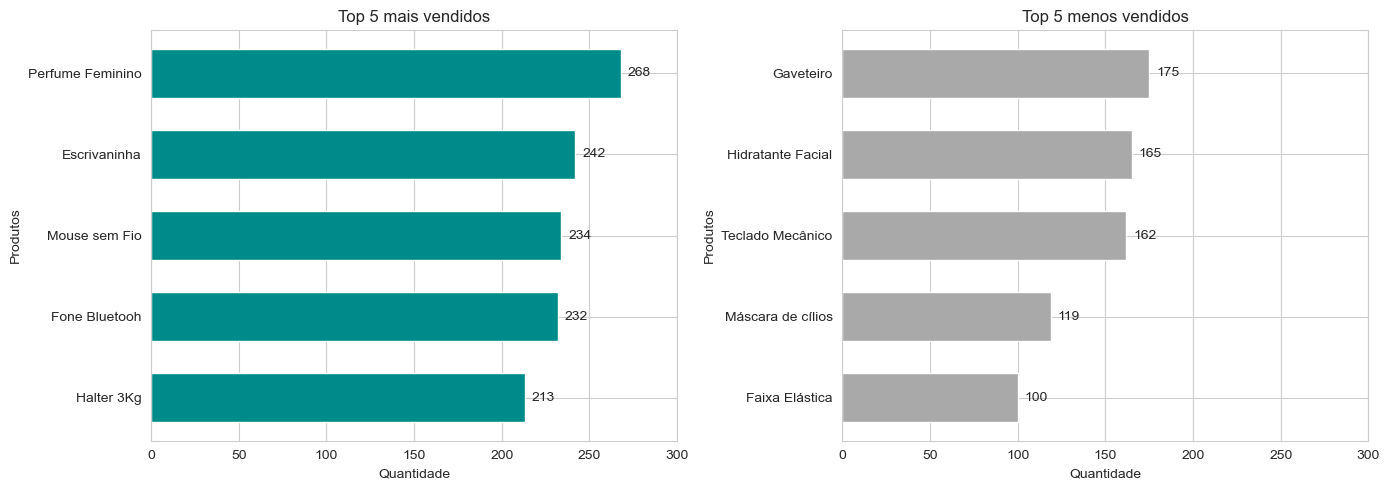

In [124]:
sns.set_style("whitegrid")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

top5mais = top5mais.sort_values()
top5menos = top5menos.sort_values()

# Coloca numeração nas barras horizontais
# .barh desenha as barras e ao mesmo tempo retorna o objeto do desenho. Salvei o objeto em barra0.
barra0 = ax[0].barh(top5mais.index, top5mais.values, color = 'darkcyan', height = 0.6)
ax[0].bar_label(barra0, padding = 5)

ax[0].set_title('Top 5 mais vendidos')
ax[0].set_xlabel('Quantidade')
ax[0].set_ylabel('Produtos')
ax[0].set_xlim(0, 300)

# Coloca numeração nas barras horizontais
barra1 = ax[1].barh(top5menos.index, top5menos.values, color = 'darkgray', height = 0.6)
ax[1].bar_label(barra1, padding = 5)

ax[1].set_title('Top 5 menos vendidos')
ax[1].set_xlabel('Quantidade')
ax[1].set_ylabel('Produtos')
ax[1].set_xlim(0, 300)


plt.tight_layout()
plt.show()

## Análise 2: Marketing direcionado

- Quais categorias tem maior faturamento?
- Quais regiões tem maior faturamento?

In [126]:
df_vendas['Categoria'].nunique()

4

In [128]:
df_vendas.groupby('Categoria')['Faturamento'].sum().sort_values(ascending = False).map('R$ {:.2f}'.format)

Categoria
Móveis         R$ 302131.58
Eletrônicos    R$ 117239.10
Beleza          R$ 50319.50
Esporte         R$ 48140.10
Name: Faturamento, dtype: object

In [135]:
faturamento_categoria = df_vendas.groupby('Categoria')['Faturamento'].sum().sort_values(ascending = False)
faturamento_categoria

Categoria
Móveis         302131.58
Eletrônicos    117239.10
Beleza          50319.50
Esporte         48140.10
Name: Faturamento, dtype: float64

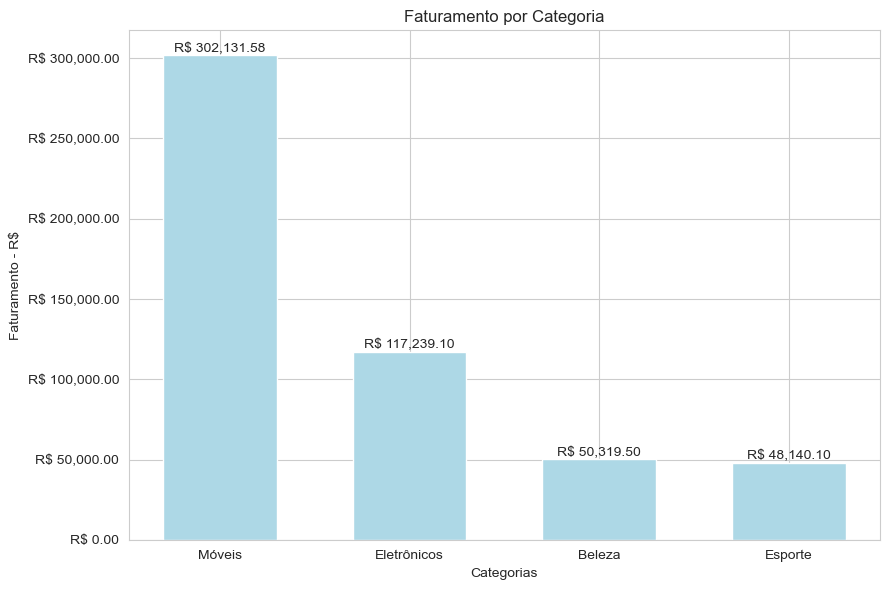

In [193]:
from matplotlib.ticker import FuncFormatter

def formata_faturamento(y, pos):

    return f'R$ {y:,.2f}'

sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(9,6))

faturamento_categoria = faturamento_categoria.sort_values(ascending = False)

# Usando a função para formatar os rótulos das barras também.
labels = [formata_faturamento(v, None) for v in faturamento_categoria.values]

barra = ax.bar(faturamento_categoria.index, faturamento_categoria.values, color = 'lightblue', width = 0.6)
ax.bar_label(barra, labels)
ax.set_title('Faturamento por Categoria')
ax.set_xlabel('Categorias')
ax.set_ylabel('Faturamento - R$')

# Criando o objeto formatador. Contém a lógica, não os dados.
formatter = FuncFormatter(formata_faturamento)
# Aplicando o formatador ao eixo y
ax.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

In [194]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_unitario,Quantidade,Estado,UF,Faturamento,Regiao
0,100,2025-01-01,Luminária LED de Mesa,Eletrônicos,79.9,4,Minas Gerais,MG,319.6,Sudeste
1,101,2025-01-01,Fone Bluetooh,Eletrônicos,149.9,3,Espírito Santo,ES,449.7,Sudeste
2,102,2025-01-02,Estante Organizadora,Móveis,286.5,2,Paraíba,PB,573.0,Nordeste
3,103,2025-01-03,Estante Organizadora,Móveis,312.5,3,Rondônia,RO,937.5,Norte
4,104,2025-01-03,Halter 3Kg,Esporte,69.9,10,Rondônia,RO,699.0,Norte


In [195]:
df_vendas['Regiao'].nunique()

5

In [202]:
faturamento_regiao = df_vendas.groupby('Regiao')['Faturamento'].sum().sort_values().head()
faturamento_regiao

Regiao
Sul              46923.81
Sudeste          63705.55
Centro-Oeste     81281.82
Norte           136648.13
Nordeste        189270.97
Name: Faturamento, dtype: float64

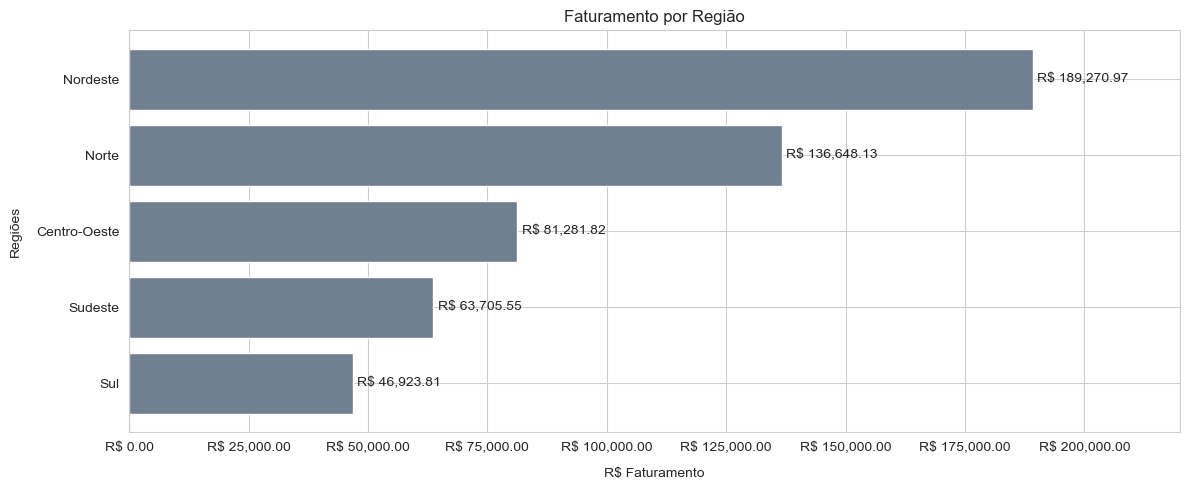

In [237]:
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize = (12,5))

def formata_faturamento(y, pos):
    return f'R$ {y:,.2f}'

formatador = FuncFormatter(formata_faturamento)
labels = [formata_faturamento(v, None) for v in faturamento_regiao.values]

barra= ax.barh(faturamento_regiao.index, faturamento_regiao.values, color = 'slategray')
ax.bar_label(barra, labels = labels, padding = 3, fontsize = 10)
ax.set_title('Faturamento por Região')

# labelpad: aumentar a distância entre o título e os elementos do eixo
ax.set_ylabel('Regiões', labelpad=10) 
ax.set_xlabel('R$ Faturamento', labelpad=10)
ax.xaxis.set_major_formatter(formatador)
ax.set_xlim(0, 220000.00)

plt.tight_layout()
plt.show()